---
# TP3 – Performance d’un classifieur 
---

---

**Nom : DIALLO**  
**Prénom : Mamadou djouldé**  
**Cursus : M1 SysCom**


--- 

## Objectif : 

On souhaite détecter les pixels de teinte chaire pour aider les algorithmes de détection de visage 
et on travaille pour cela sur des images de la base Pratheepan Dataset  (W.R. Tan, C.S. Chan, 
Y. Pratheepan and J. Condell (2012) "A Fusion Approach for Efficient Human Skin Detection", 
IEEE Transactions on Industrial Informatics). Dans cette base, la vérité de terrain a été 
déterminée pour chaque image. 

- Import des bibliothèques nécessaires

In [98]:
import time
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.decomposition import PCA 

- import des fonctions du fichier TP3_ETU.py

In [100]:
from TP3_ETU import calcul_moyenn_ecartype, vraisemblance, methode_du_sujet, classifieur, courbe_ROC, Loi_normale2D

--- 
---
## I. Chargement et visualisation des données 

- Code de base fourni par le TP

In [102]:
# from fn import norm1, norm2
import os
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal, norm
from PIL import Image

DATA_PATH = 'DATA/'

image_ext = ['.jpg']
images =  [os.path.join(DATA_PATH, f) for f in sorted(os.listdir(DATA_PATH)) if f.endswith(".jpg")]

X_train=np.empty((0, 2))
y_train=[]
for name in images[0:-4]:
    I= Image.open(name)
    I = I.convert('YCbCr')
    I = np.array(I)
    I=np.reshape(I[:,:,1:3],[I.shape[0]*I.shape[1],2])
    X_train = np.concatenate((X_train, I), axis=0)
    fichier_png= os.path.splitext(name)[0] + ".png"
    GT = Image.open(fichier_png)
    GT = np.array(GT)
    GT=np.reshape(GT[:,:,1]/255,[GT.shape[0]*GT.shape[1]])
    y_train = np.concatenate((y_train, GT), axis=0)


X_test=np.empty((0, 2))
y_test=[]
for name in images[-4:]:
    I= Image.open(name)
    I = I.convert('YCbCr')
    I = np.array(I)
    I=np.reshape(I[:,:,1:3],[I.shape[0]*I.shape[1],2])
    X_test = np.concatenate((X_test, I), axis=0)
    fichier_png= os.path.splitext(name)[0] + ".png"
    GT = Image.open(fichier_png)
    GT = np.array(GT)
    GT=np.reshape(GT[:,:,1]/255,[GT.shape[0]*GT.shape[1]])
    y_test = np.concatenate((y_test, GT), axis=0)

X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

X_train, pipo, y_train, pipo = train_test_split(X_train, y_train, train_size=1/1000, random_state=52)
X_test, pipo, y_test, pipo = train_test_split(X_test, y_test, train_size=1/1000, random_state=52)


- Observons les images dans l’explorateur de fichiers puis Étudions et exécutons le programme TP3_ETU. 

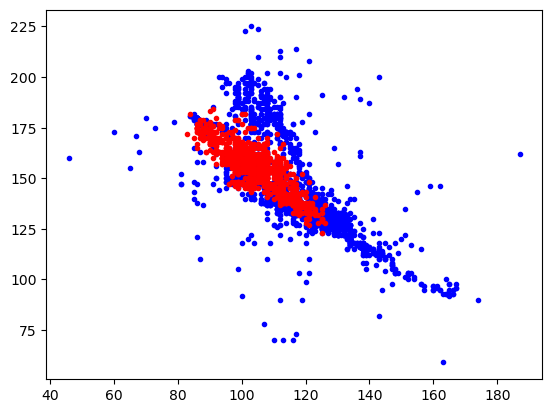

In [104]:
#Pixel peau
Peau_Train = X_train[np.where(y_train==1),:]
Peau_Train = np.reshape(Peau_Train,(Peau_Train.shape[1],Peau_Train.shape[2] ))
#Pixel non peau
Nonpeau_Train = X_train[np.where(y_train==0),:]
Nonpeau_Train = np.reshape(Nonpeau_Train,(Nonpeau_Train.shape[1],Nonpeau_Train.shape[2] ))


plt.plot(Nonpeau_Train[:,0], Nonpeau_Train[:,1], '.b', label='Non peau')
plt.plot(Peau_Train[:,0], Peau_Train[:,1], '.r', label='Peau')
plt.show()

In [105]:
print("Dimension de la base d'apprentissage pour 1/1000 de tous les pixels : ",X_train.shape)
print("\nDimension de la base de test pour 1/1000 de tous les pixels : ",X_test.shape)



Dimension de la base d'apprentissage pour 1/1000 de tous les pixels :  (4739, 2)

Dimension de la base de test pour 1/1000 de tous les pixels :  (566, 2)


In [106]:
print("\nNombre d'exemple de la classe peau : ", Peau_Train.shape[0])
print("\nNombre d'exemple de la classe non peau",Nonpeau_Train.shape[0])


Nombre d'exemple de la classe peau :  1179

Nombre d'exemple de la classe non peau 3560


---
### Reponse I : 

- La base d'apprentissage et de test sont constitués des pixels des images du dossier DATA.
La base d'apprentissage utilise toutes les images sauf 4 qui sont resevées à la base de test
Chaque pixel est decrit par 2 valeurs Cb et Cr
Avec la partition aléatoire fournie par le code, on a trop de pixels et les 4739 correspondent à 1/1000 de tous les pixels.

- La dimension des données pour X_train et X_test est de 2.

- On a 2 classes : peau et nonpeau, et pour chaque classe on a respectivement 1248 et 3491 exemples. Ces valeurs ne concernent que les 1/1000 du total des pixels.
---

--- 
--- 

- Afin d’avoir des temps de calcul raisonnables, on conservera pour la suite 1 pixel sur 1000 pour 
les bases d’apprentissage et de test (on pourra utiliser 2 fois la fonction train_test_split). Pour 
reproductibilité lors de la correction, la variable random_state correspondra aux trois derniers 
chiffre mon numéro étudiant(052). 

---
--- 

## II. Modélisation de la vraisemblance des observations par une loi normale 2D avec des dimensions décorrélées


### Objectif II.a : 
Comme il est difficile de modéliser tout ce qui n'est pas teinte chaire, on decide de travailler avec une seule classe, la teinte chaire, dont on estime la vraisemblance des observations P(x/chair).e

#### a. Estimation de la vraisemblance des observations des pixels de teinte chaire

Faute d'une mauvaise lecture du sujet j'avais trouvé une autre methode pour calculer la vraisemblance avant de voir la methode imposée,
Néanmoins j'ai aussi appliqué la méthode imposée par le sujet qui aboutit au même résultat.

In [112]:
""" Faute d'une mauvaise lecture du sujet j'avais trouvé une autre methode pour calculer la vraisemblance avant de voir la methode imposée,
    Néanmoins j'ai aussi appliqué la méthode imposée par le sujet qui aboutit au même résultat."""
methode_sujet = 1
methode_djoulde = 0  # Changez le 0 en 1 pour calculer la vraisemblance avec une autre methode que celle imposée par le sujet


if(methode_sujet) :
    # Affichage du resultat des moyennes et écarts types des composantes Cb et Cr 
    p_train, mCb, mCr, ecart_typeCb, ecart_typeCr = methode_du_sujet(Peau_Train)

    # Affichage de la vraisemblance
    print("\nMoyenne Cb :", mCb)
    print("Moyenne Cr :", mCr)
    print("Écart-type Cb :", ecart_typeCb)
    print("Écart-type Cr :", ecart_typeCr)
    print("vraisemblance des observations des 5 premiers pixels de teinte chaire p(x/chair) :", p_train[:5])

#--------------------------------------------------------------------------------------------------------   
if (methode_djoulde) : 
    # Affichage du resultat des moyennes et écarts types des composantes Cb et Cr 
    mCb, mCr,ecart_typeCb, ecart_typeCr = calcul_moyenn_ecartype(Peau_Train)
    print("\nMoyenne Cb (mCb) :", mCb)
    print("Moyenne Cr (mCr) :", mCr)
    print("Écart-type Cb (oCb) :", ecart_typeCb)
    print("Écart-type Cr (oCr) :", ecart_typeCr)

    # Affichage de la vraisemblance
    p_train = vraisemblance(Peau_Train, mCb, mCr, ecart_typeCb, ecart_typeCr)
    print("vraisemblance des observations des 5 premiers pixels de teinte chaire p(x/chair) :", p_train[:5]) 
#--------------------------------------------------------------------------------------------------------- 


Moyenne Cb : 104.57506361323155
Moyenne Cr : 154.9991518235793
Écart-type Cb : 8.762830499514054
Écart-type Cr : 11.154972766957883
vraisemblance des observations des 5 premiers pixels de teinte chaire p(x/chair) : [1.50397563e-03 7.10909841e-04 8.21258717e-04 5.63406722e-05
 1.10268381e-03]


In [113]:
print('Affichage des dimensions : \nmCb :',mCb.shape, '\nmCr :', mCr.shape,'\necart_typeCb :',ecart_typeCb.shape, '\necart_typeCr :', ecart_typeCr.shape, '\nP(𝒙/𝑐ℎ𝑎𝑖𝑟) :', p_train.shape, '\nP_train :', p_train.shape)

Affichage des dimensions : 
mCb : () 
mCr : () 
ecart_typeCb : () 
ecart_typeCr : () 
P(𝒙/𝑐ℎ𝑎𝑖𝑟) : (1179,) 
P_train : (1179,)


---
### Reponse II.a : 

1. Les variables sont indicées par Cb et Cr parceque l'image a été convertie en espace YCbCr, et pour detecter la peau on ne s'interesse qu'aux composantes Cb et Cr. (Y correspond à l'intensité de la lumière, Cb indique la quantité de bleu du pixel par rapport à la lumiere, et Cr indique la quantité de rouge du pixel par rapport à la lumiere).

2. Les quatres valeurs ne sont pas des tableaux, ni des autre chose, c'est simplement des scalaires ou des valeures calculées sur l'ensemble des pixels de la teinte chaire.

3. La vraisemblance P(x/chair) est un scalaire de dimension 1, C'est juste une valeur de probabilité sur la ressemblance du pixel à la teinte chaire.

4. Le vecteur p_train est de dimension (N, 1) (affiché sous la forme (1179,), il contient une valeur scalaire de vraisemblance pour chaque pixel de teinte chaire de la base d'apprentissage.

5. Dans la méthode précédente, on a appliqué pratiquement la formule de la probabilité conjointe des gaussiennes, ce qui correspond au produit des probabilités marginales, et cela met en avant une condition à son application : Cb et Cr doivent être indépendants **(l'hypothese se base sur l'indépendance de Cb et Cr)**.

---

### Objectif II.b : 

Pour réaliser la classification, on seuillera la vraisemblance des observations P(x/chair) de la base de test.
N’ayant aucune idée du seuil à utiliser, on met le classifieur au point sur la base d’apprentissage en utilisant comme seuil la valeur moyenne de p_train.

#### b. Mise en place du classifieur : 

- Determinons le seuil : 

In [117]:
seuil = np.mean(p_train)
print("La valeur de seuil qu'on va utiliser est :", seuil)


La valeur de seuil qu'on va utiliser est : 0.0008807345363627743


- Si la vraisemblance P(x/chair) est superieur ou egale à la valeur de seuil on predit **<< peau >>** sinon on predit **<< non-peau>>**. Pour faire cela, on va calculer la vraisemblance pour tous les pixels de la base d'apprentissage, Ma methode a consisté à utiliser la fonction **methode_du_sujet** que j'avais definie dans TP3_ETU.py qui estime la vraisemblance p(x/chair) sur la base d'apprentissage et aussi par la suite de crée une fonction classifieur qui fait la classification selon le seuil et qui affiche TP, TN, FP, FN, la sensibilité, la spécificité, et le taux de bonne reconnaissance en utilisant les formules et methodes vues en cours.

##### Méthode utilisée pour le classifieur

- Si la vraisemblance P(x/Chair) d’un pixel est **supérieure ou égale au seuil**, on prédit que le pixel est « peau », sinon on prédit « non-peau ».

- Je calcule la vraisemblance pour tous les pixels de la base d’apprentissage en utilisant la fonction `methode_du_sujet` définie dans `TP3_ETU.py`. Cette fonction estime les moyennes et écarts-types des composantes Cb et Cr et calcule la vraisemblance selon une loi normale 2D avec dimensions décorrélées.
 
- Je crée par la suite une fonction `classifieur` qui effectue la classification selon le seuil et calcule :  
  - TP, TN, FP, FN, Sensibilité, spécificité et le taux de reconnaissance.

In [120]:
p_tous_pixels = methode_du_sujet(X_train)[0]  # fonction methode_du_sujet

resultats = classifieur(y_train, p_tous_pixels, seuil) # Appel de la fonction classieur du fichier TP3_ETU.py

TP = 0 TN = 3560 FP = 0 FN = 1179
Sensibilité : 0.0
Spécificité : 1.0
Taux de bonne reconnaissance : 0.7512133361468665


##### Interpretation du resultat :

- Avec cette valeur de seuil, on peut voir que tous les pixels non-peau sont détectés (TN = 3560), mais aucun pixel peau n'est détecté (TP = 0), ce qui explique qu'on a une sensibilité nulle et une spécificité maximale. Le taux de reconnaissance est d'environ 75 %, et c'est tout simplement parce que les pixels non-peau sont largement plus nombreux que les pixels peau. Cette valeur de taux de reconnaissance est logique dans ce contexte, mais ne signifie pas que la valeur de seuil est bien choisie.

---
### Reponse II.b : 

1. Signification de TP,TN,FP,FN :
   - TP (Vrai Positif) : correspond aux pixels peau correctement détectés.
   - TN (Vrai Negatif) : correspond aux pixels non-peau correctement détectés.
   - FP (Faux Positif) : correspond aux pixels non-peau qui sont détectés comme etant des pixels peau.
   - FN (Faux Negatif) : correspond aux pixels peau qui sont détectés comme etant des pixels non peau.


2. Estimation de la sensibilité et de la spécificité :

 - Sensibilité : Correspond à la capacité de notre système à bien detecter les pixels peau dont voici la formule vue en cours :

$$
\text{Sensibilité} = \frac{TP}{TP + FN}
$$
    
   - Spécificité : Dans notre cas c'est la capacité de notre système à detecter les pixels non peau dont voici la formule :

$$
\text{Spécificité} = \frac{TN}{TN + FP}
$$

3. Pour estimer le taux de bonne reconnaissance, on utilise la formule vue en cours :

$$
\text{Taux de bonne classification (accuracy)} = \frac{TP + TN}{TP + TN + FP + FN}
$$

4. Le seuil initial est la moyenne de P(x/chair) sur la base d'apprentissage. Cela permet ensuite d'ajuster facilement le seuil en l'augmentant ou en le diminuant selon les résultats car on avait aucune information à priori nous indiquant comment choisir le seuil.

---

In [123]:
NB = 20 
SEUILS = np.linspace(np.min(p_train), np.max(p_train), NB)
print("Les seuils que nous allons utiliser pour la suite sont :\n ", SEUILS)

Les seuils que nous allons utiliser pour la suite sont :
  [1.75828933e-06 8.72596775e-05 1.72761066e-04 2.58262454e-04
 3.43763842e-04 4.29265230e-04 5.14766618e-04 6.00268006e-04
 6.85769395e-04 7.71270783e-04 8.56772171e-04 9.42273559e-04
 1.02777495e-03 1.11327634e-03 1.19877772e-03 1.28427911e-03
 1.36978050e-03 1.45528189e-03 1.54078328e-03 1.62628466e-03]


### Objectif II.c : 

Plutôt que de choisir un seuil arbitraire, on choisit 20 valeurs de seuils régulièrement réparties 
entre min(p_train) et max(p_train). 

#### c. Courbe de ROC
- Pour chaque valeur de seuil, estimons la précision et le rappel 
et traçons la courbe ROC.

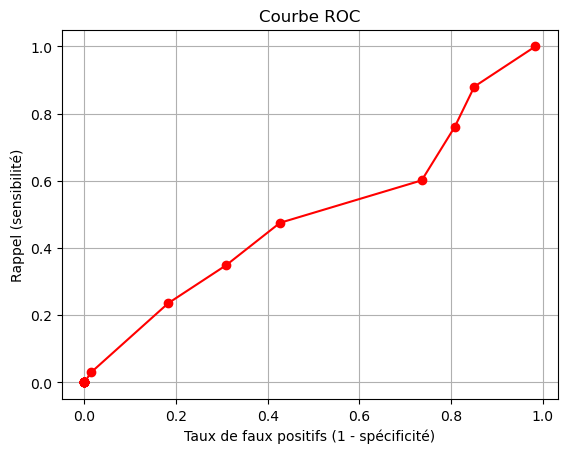

In [126]:
# Appel de la fonction courbe_ROC du fichier TP3_ETU.py pour tracer la courbe de ROC
faux_pos, rappels = courbe_ROC(y_train, p_tous_pixels, SEUILS)

- On va chercher le seuil pour le quel rappel ≈ spécificité en utilisant la fonction classifieur dans TP3_ETU.py pour calculer et afficher le taux de reconnaissance pour le seuil qu'on aura trouvé.

In [128]:
# Calcul de la spécificité
specificites = 1 - np.array(faux_pos)

# Chercher le seuil où rappel ≈ spécificité
seuil_equilibre = SEUILS[0]
plus_petite_diff = abs(rappels[0] - specificites[0])

for i in range(1, len(SEUILS)):
    diff = abs(rappels[i] - specificites[i])
    if diff < plus_petite_diff:
        plus_petite_diff = diff
        seuil_equilibre = SEUILS[i]

print("Seuil choisi pour avoir rappel ≈ spécificité :", seuil_equilibre)

# Appel de la fonction classifieur pour calculer le taux de bonne reconnaissance
classifieur(y_train, p_tous_pixels, seuil_equilibre)


Seuil choisi pour avoir rappel ≈ spécificité : 0.00034376384191901874
TP = 560 TN = 2041 FP = 1519 FN = 619
Sensibilité : 0.47497879558948264
Spécificité : 0.5733146067415731
Taux de bonne reconnaissance : 0.5488499683477527


---
### Reponse II.c : 
- En observant la courbe ROC, visuellement on voit un point où le rappel est d’environ 0.5 et où 1 - spécificité est d’environ 0.42. Ce point peut servir à choisir un seuil qui équilibre à peu près le taux de vrais positifs et de vrais négatifs.

- Les valeurs trouvées apres execution du code pour ce point sont : 
    - TP = 560
    - TN = 2041 
    - FP = 1519 
    - FN = 619
- Pour determiner le taux de reconnaissance pour ce point on a appliqué la formule : 

$$
\text{Taux de bonne reconnaissance (accuracy)} = \frac{TP + TN}{TP + TN + FP + FN} ≈ 0.5488
$$
---

#### d. classification des pixels de test :

Avec le seuil qu'on a trouvé precedement, determinons le taux de bonne classification des pixels de test. Pour cela on va calculer la vraisemblance de test puis utiliser la fonction classifieur pour calculer le taux de bonne classification.

In [131]:

# d. Classification des pixels de test 
p_test = methode_du_sujet(X_test)[0]  # vraisemblances des pixels de test

# Appel de la fonction classifieur pour calculer le taux de bonne classification des pixels de test
classifieur(y_test, p_test, seuil_equilibre)

TP = 114 TN = 277 FP = 146 FN = 29
Sensibilité : 0.7972027972027972
Spécificité : 0.6548463356973995
Taux de bonne reconnaissance : 0.6908127208480566


---
### Reponse II.d : 

Avec le seuil choisi pour avoir rappel ≈ spécificité sur la base d’apprentissage, nous avons appliqué le classifieur aux pixels de test.

Les résultats obtenus sont :

- TP = 114
- TN = 277
- FP = 146
- FN = 29
- Sensibilité (rappel) = 0.797
- Spécificité = 0.65

- Taux de bonne classification ≈ 69 %

Avec ces resultats on peut dire qu'on a trouvé un seuil optimal qui permet de detecter à la fois les pixels peau et non peau.

---


---
---

---
---
## III. Modélisation de la vraisemblance des observations par une loi normale 2D 

Reprenons la partie II en utilisant une loi normale 2D définie par :

$$
p(\mathbf{x}) = \frac{1}{2\pi\,\det(\Sigma)}\,
\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\mathbf{m})^\top \Sigma^{-1} (\mathbf{x}-\mathbf{m})\right)
$$



- Je calcule la vraisemblance 2D des pixels de peau en réutilisant la même methode de la partie II mais cette fois en utilisant la methode complete. 

In [136]:
# Appel de la fonction Loi_normale2D pour appliquer la méthode 2D complète
p_train_2D, m, cov = Loi_normale2D(Peau_Train, X_train)

print("Moyenne :\n", m)
print("Matrice de covariance :\n", cov)
print("Vraisemblance des 5 premiers pixels :", p_train_2D[:5])

Moyenne :
 [104.57506361 154.99915182]
Matrice de covariance :
 [[ 76.85238274 -82.82039468]
 [-82.82039468 124.53904852]]
Vraisemblance des 5 premiers pixels : [9.26606550e-04 1.11697678e-03 1.01616448e-05 1.99590978e-04
 2.92504992e-03]


- Je détermine le seuil de classification en prenant la moyenne des vraisemblances 2D calculées sur la base d’apprentissage.

In [138]:
# Seuil : moyenne des vraisemblances sur la base d'apprentissage
seuil_2D = np.mean(p_train_2D)
print("\nSeuil pour la loi normale 2D complète :", seuil_2D)


Seuil pour la loi normale 2D complète : 0.0006764636987572393


- J’applique le classifieur sur les pixels d’apprentissage en utilisant les vraisemblances 2D et le seuil calculé.


In [140]:
# Classification sur la base d'apprentissage
print("\nRésultats sur la base d'apprentissage (2D complète) :")
classifieur(y_train, p_train_2D, seuil_2D)


Résultats sur la base d'apprentissage (2D complète) :
TP = 929 TN = 2828 FP = 732 FN = 250
Sensibilité : 0.7879558948261238
Spécificité : 0.7943820224719101
Taux de bonne reconnaissance : 0.7927832876134205


- Je trace la courbe ROC pour la vraisemblance 2D en réutilisant la fonction courbe_ROC déjà définie dans la partie II.


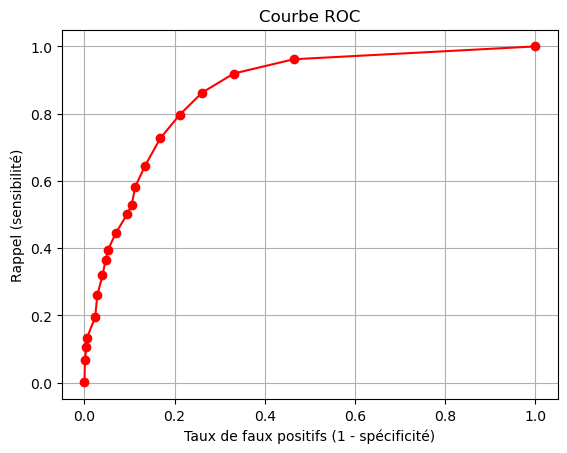

In [142]:
# Détermination des seuils
SEUILS_2D = np.linspace(np.min(p_train_2D), np.max(p_train_2D), NB)
# Tracé de la courbe ROC
faux_pos_2D, rappels_2D = courbe_ROC(y_train, p_train_2D, SEUILS_2D)

- Je calcule le seuil d’équilibre où rappel ≈ spécificité en réutilisant la même logique que pour la méthode décorrélée.


In [144]:
specificites_2D = 1 - np.array(faux_pos_2D)

seuil_equilibre_2D = SEUILS_2D[0]
plus_petite_diff = abs(rappels_2D[0] - specificites_2D[0])

for i in range(1, len(SEUILS_2D)):
    diff = abs(rappels_2D[i] - specificites_2D[i])
    if diff < plus_petite_diff:
        plus_petite_diff = diff
        seuil_equilibre_2D = SEUILS_2D[i]
print("\nSeuil choisi pour rappel ≈ spécificité (2D complète) :", seuil_equilibre_2D)


Seuil choisi pour rappel ≈ spécificité (2D complète) : 0.0006407429659367681


- Je calcule les vraisemblances des pixels de test avec la loi normale 2D complète et j’évalue les performances en réutilisant la fonction de classification existante.


In [146]:
# Vraisemblances des pixels de test
p_test_2D, _, _ = Loi_normale2D(Peau_Train, X_test)
print("\nRésultats sur la base de test (2D complète) :")
classifieur(y_test, p_test_2D, seuil_equilibre_2D)


Résultats sur la base de test (2D complète) :
TP = 130 TN = 338 FP = 85 FN = 13
Sensibilité : 0.9090909090909091
Spécificité : 0.7990543735224587
Taux de bonne reconnaissance : 0.8268551236749117


--- 
### Reponse III : Comparaison entre les deux methodes : 

En observant les résultats des parties II et III distinctement, on voit une grande différence, non seulement sur la courbe de la méthode III qui paraît plus réaliste, mais aussi dans le fait que la méthode 2D complète améliore tous les indicateurs par rapport à la méthode 2D décorrélée. 

- Sensibilité : 2D complète 0.787 vs 2D décorrélée 0.47 - **bien meilleure pour détecter les pixels de peau**.

- Spécificité : 2D complète 0.794 vs 2D décorrélée 0.57 - **moins de faux positifs**.

- Accuracy : 2D complète 0.79 vs 2D décorrélée 0.55 - **meilleure classification globale**.

---


---
---

---
---
## IV. Test sur une nouvelle image

Réalisons la détection des pixels de teinte chaire sur l’image ‘image.jpg’. 

Pour faire cela on va utiliser la methode appliquée en III.

- Pour un premier temps on va charger l'image 

In [151]:
# Chargement de l'image
img = Image.open('image.jpg').convert('YCbCr')
img_array = np.array(img)
X_img = img_array[:, :, 1:3].reshape(-1, 2).astype('float64')

- Calculons les vraisemblances avec la loi normale 2D complète

In [153]:
p_img, _, _ = Loi_normale2D(Peau_Train, X_img)

- Classifions les pixels selon le seuil choisi (seuil_equilibre_2D) et remettons sous forme image

In [155]:
mask = (p_img >= seuil_equilibre_2D).astype(np.uint8)

# Remettre sous forme image
mask_img = mask.reshape(img_array.shape[0], img_array.shape[1])

- Affichage du resultat 

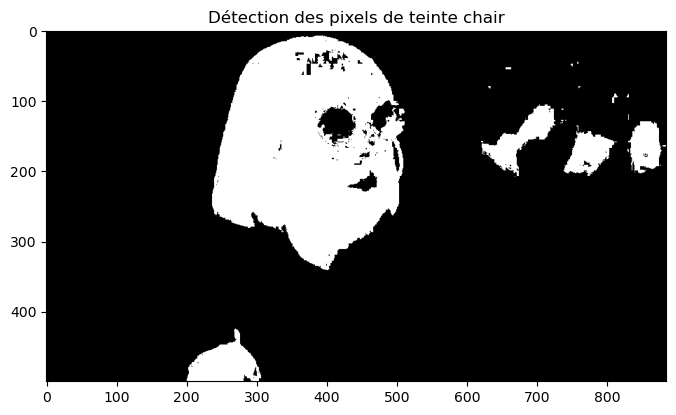

In [157]:
plt.figure(figsize=(8, 6))
plt.imshow(mask_img, cmap='gray')
plt.title("Détection des pixels de teinte chair")
plt.show()


##### Remarque : 
La zone blance correspond aux pixels qui ont été détectés comme peau et la zone noire correspond aux pixels qui sont détéctés comme non-peau.


---
---

---
---
## Conclusion Générale : 

La modélisation des pixels de peau par une loi normale 2D permet de détecter efficacement les zones de teinte chair. L’usage du seuil issu de la courbe ROC améliore la classification par rapport à un seuil arbitraire.


---
---